In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib 

In [2]:
df=pd.read_csv("../data/engineered_car_data.csv")
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Mileage_per_Year,Log_Selling_Price,Log_Kms_Driven,Age_Group
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,2250.000000,1.208960,10.203592,Old
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,3307.692308,1.558145,10.668955,Old
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,766.666667,1.981001,8.839277,Medium
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,346.666667,1.047319,8.556414,Old
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,3537.500000,1.526056,10.656082,Old


In [3]:
X=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]
print(X.shape)
print(y.shape)

(301, 12)
(301,)


In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(240, 12)
(61, 12)


In [5]:
print(X.dtypes)

Year                   int64
Present_Price        float64
Kms_Driven             int64
Fuel_Type                str
Seller_Type              str
Transmission             str
Owner                  int64
Car_Age                int64
Mileage_per_Year     float64
Log_Selling_Price    float64
Log_Kms_Driven       float64
Age_Group                str
dtype: object


In [6]:
df["Age_Group"] = df["Age_Group"].fillna("Old")

In [7]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Age_Group"],
    drop_first=True
)

In [8]:
X = df.drop(["Selling_Price", "Log_Selling_Price"], axis=1)

y = df["Selling_Price"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2: 0.8469214141937638
MAE: 1.253820981091535
MSE: 3.526254701586056
RMSE: 1.8778324476869752


In [12]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
print("Ridge Regression :")
print("R2:", ridge_r2)
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)

Ridge Regression :
R2: 0.8485002629289615
MAE: 1.2433210000044725
MSE: 3.489884998101657
RMSE: 1.8681233894209603


In [13]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
lasso_r2=r2_score(y_test, y_pred_lasso)
lasso_mae=mean_absolute_error(y_test,y_pred_lasso)
lasso_mse=mean_squared_error(y_test,y_pred_lasso)
lasso_rmse=np.sqrt(lasso_mse)
print("Lasso Regression :")
print("R2:", lasso_r2)
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)

Lasso Regression :
R2: 0.8486469525201095
MAE: 1.2115261082294226
MSE: 3.48650591762652
RMSE: 1.8672187653369703


In [14]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(elastic_mse)

print("R2:", elastic_r2)
print("MAE:", elastic_mae)
print("MSE:", elastic_mse)
print("RMSE:", elastic_rmse)

R2: 0.8518148937718757
MAE: 1.2026744214101934
MSE: 3.4135305391661452
RMSE: 1.8475742310300134


In [15]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
param_grid={
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}
grid = GridSearchCV(ElasticNet(),param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.2}
Best Score: 0.8322452364851189


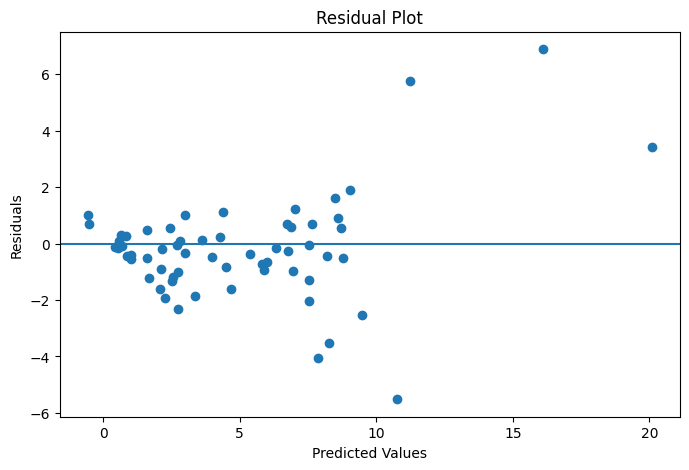

In [17]:
import matplotlib.pyplot as plt
residuals=y_test-y_pred_elastic
plt.figure(figsize=(8,5))
plt.scatter(y_pred_elastic,residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

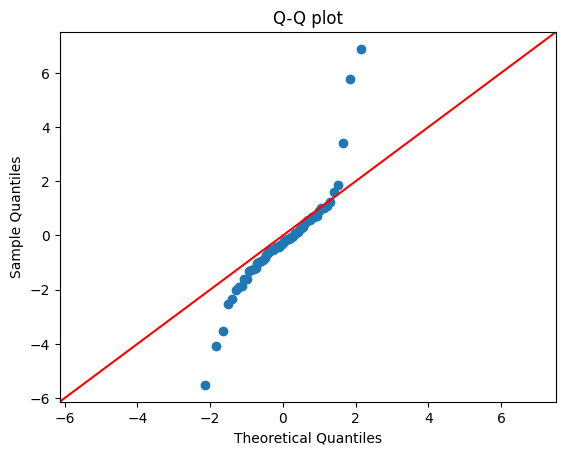

In [18]:
import statsmodels.api as sm
sm.qqplot(residuals,line='45')
plt.title("Q-Q plot")
plt.show()

In [19]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": elastic.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df)

                   Feature  Coefficient
7         Fuel_Type_Diesel     0.669624
1            Present_Price     0.466174
0                     Year     0.194103
6           Log_Kms_Driven     0.000000
2               Kms_Driven    -0.000003
5         Mileage_per_Year    -0.000016
11           Age_Group_Old    -0.056961
3                    Owner    -0.152108
4                  Car_Age    -0.193968
8         Fuel_Type_Petrol    -0.474078
10     Transmission_Manual    -0.613837
9   Seller_Type_Individual    -0.711181


In [21]:
X_sm = X_train.astype(float)
X_sm = sm.add_constant(X_sm)

model_sm = sm.OLS(y_train, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     169.2
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          4.86e-103
Time:                        19:58:17   Log-Likelihood:                -467.69
No. Observations:                 240   AIC:                             959.4
Df Residuals:                     228   BIC:                             1001.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [22]:
import joblib

joblib.dump(elastic, "../src/best_car_price_model.pkl")

print("Best Model Saved Successfully")

Best Model Saved Successfully
